# Task 1: Data Merge + EDA

In [25]:
!git clone https://github.com/hasby-umutoniwabo/Data-Preprocessing-Formative.git
%cd Data-Preprocessing-Formative
!pip install -q -r requirements.txt

Cloning into 'Data-Preprocessing-Formative'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (112/112), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 112 (delta 29), reused 102 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (112/112), 3.38 MiB | 28.14 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/Data-Preprocessing-Formative/Data-Preprocessing-Formative/Data-Preprocessing-Formative


In [26]:
# Load the raw data
import sys
sys.path.append("scripts")
import merge_data

social, transactions = merge_data.load_data()
social.head()

,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral


In [27]:
# Run EDA: dtypes, summary stats, 4 labeled plots
merge_data.run_eda(social, transactions)

=== Social profiles: dtypes ===
customer_id_new             object
social_media_platform       object
engagement_score             int64
purchase_interest_score    float64
review_sentiment            object
dtype: object

=== Social profiles: summary stats ===
       customer_id_new social_media_platform  engagement_score  \
count              155                   155        155.000000   
unique              84                     5               NaN   
top               A155               Twitter               NaN   
freq                 7                    38               NaN   
mean               NaN                   NaN         75.606452   
std                NaN                   NaN         14.568021   
min                NaN                   NaN         50.000000   
25%                NaN                   NaN         63.500000   
50%                NaN                   NaN         77.000000   
75%                NaN                   NaN         87.500000   
max          

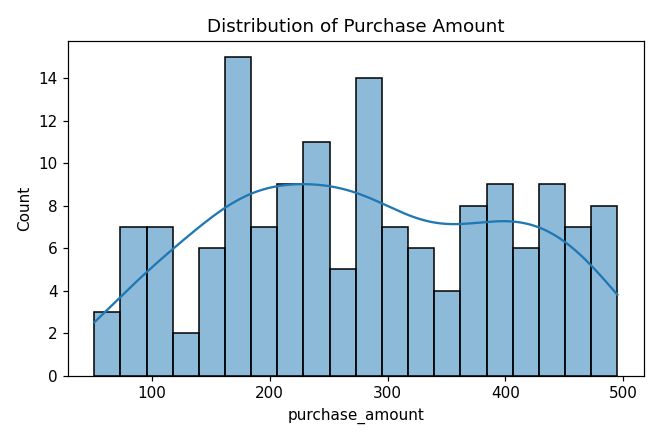

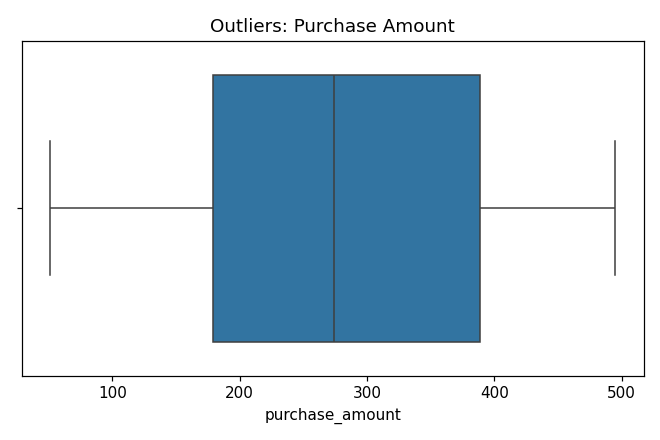

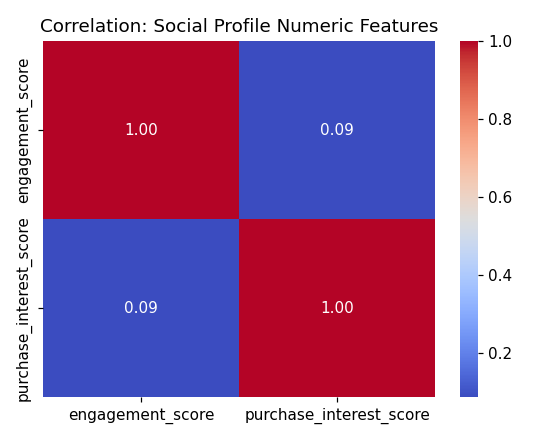

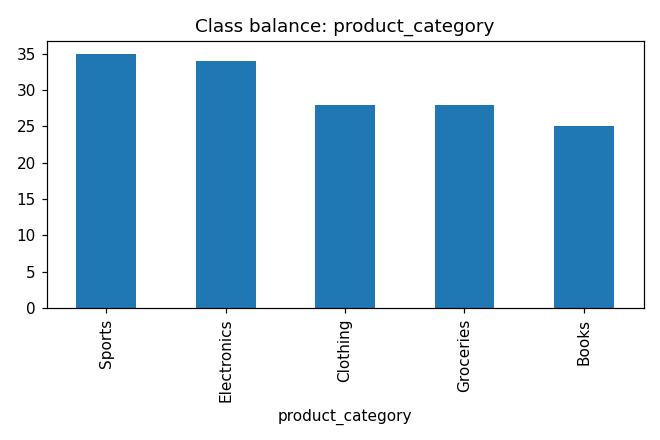

In [28]:
# Show the EDA plots inline
from IPython.display import Image, display
for f in ["dist_purchase_amount.png", "outliers_purchase_amount.png",
          "correlation_social.png", "target_class_balance.png"]:
    display(Image(filename=f"data/processed/eda_plots/{f}"))

In [29]:
# Clean both datasets (dedupe, normalize IDs, fill missing ratings)
social_clean = merge_data.clean_social(social)
transactions_clean = merge_data.clean_transactions(transactions)
social_clean.head()

Dropped 5 exact duplicate social profile row(s)
Aggregated social profiles: 150 rows -> 84 customers
Dropped 0 duplicate transaction row(s)
Filled 10 missing customer_rating value(s) with median (3.0)


,customer_id,engagement_score,purchase_interest_score,social_media_platform,review_sentiment
0,100,77.000000,4.400000,Instagram,Negative
1,101,68.000000,1.000000,Twitter,Neutral
2,102,51.000000,4.800000,LinkedIn,Neutral
3,103,64.333333,2.866667,Instagram,Positive
4,104,83.000000,2.933333,Twitter,Negative


In [30]:
# Merge + validate row counts / unmatched IDs / nulls
merged = merge_data.merge_and_validate(social_clean, transactions_clean)
merged.head()


=== Merge validation ===
Social customers      : 84
Transaction rows      : 150
Merged rows           : 117
Transactions with no matching social profile (dropped): 14
Nulls remaining after merge:
none


,customer_id,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,engagement_score,purchase_interest_score,social_media_platform,review_sentiment
0,151,1001,408,2024-01-01,Sports,2.3,71.666667,2.166667,Twitter,Neutral
1,192,1002,332,2024-01-02,Electronics,4.2,60.000000,4.300000,Instagram,Positive
2,114,1003,442,2024-01-03,Electronics,2.1,87.000000,4.800000,Facebook,Negative
3,160,1005,64,2024-01-05,Clothing,1.3,72.666667,2.500000,Instagram,Neutral
4,120,1006,395,2024-01-06,Groceries,1.1,77.000000,2.666667,Instagram,Positive


In [31]:
# Add engineered features, save the final dataset
merged = merge_data.engineer_features(merged)
merged.to_csv("data/processed/merged_dataset.csv", index=False)
merged.shape

(117, 12)

In [32]:
!echo "__pycache__/" >> .gitignore
!git add .gitignore
!git commit -m "Ignore pycache"
!git push

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@962fa1753b7f.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


# Task 2: Image Pipeline

Found 9 real image(s) in data/images/
Saved preview grid -> data/images/_sample_preview.png
Saved 36 feature rows (325 columns) -> data/image_features.csv


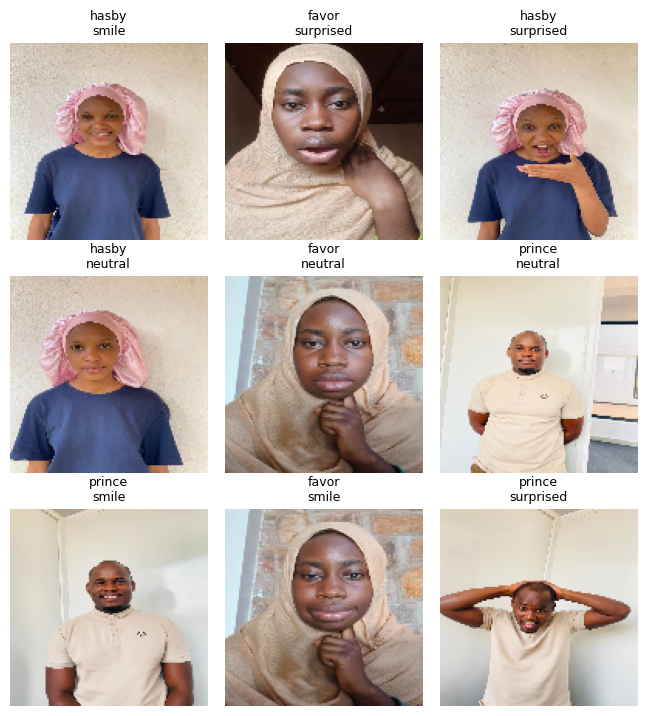

In [33]:
# Load images (placeholders for now), preview them, augment + extract features
import sys
sys.path.append("scripts")
import image_pipeline
image_pipeline.main()

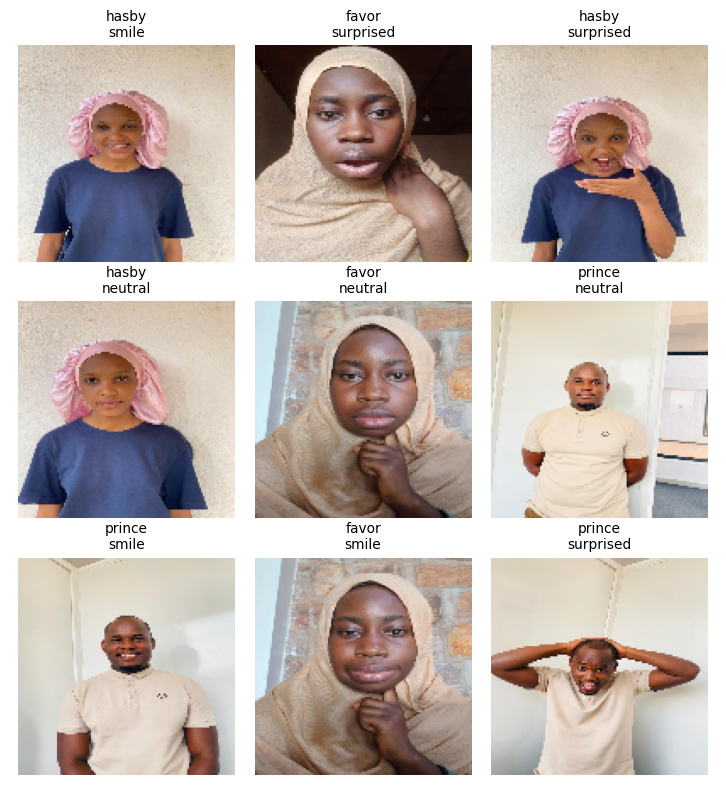

In [34]:
# Show the sample face preview inline
from IPython.display import Image, display
display(Image(filename="data/images/_sample_preview.png"))

# Task 3: Audio Pipeline

Found 6 real recording(s) in data/audio/
Saved waveform + spectrogram preview -> data/audio/_sample_preview.png
Saved 24 feature rows (34 columns) -> data/audio_features.csv


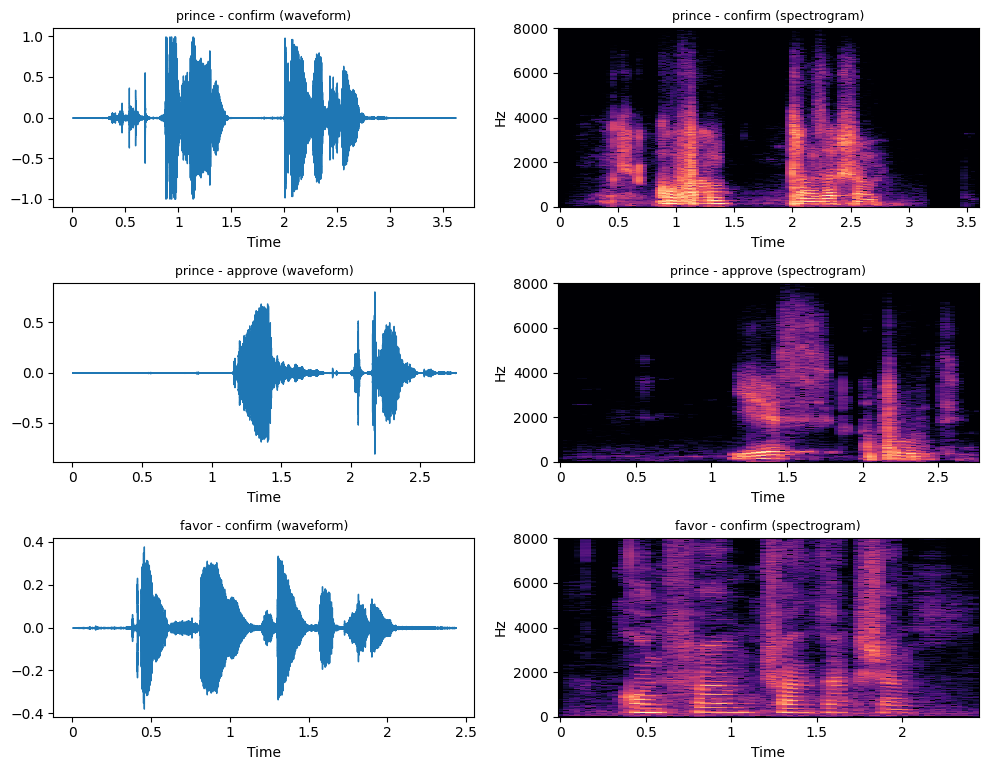

In [35]:
# Load audio (placeholders for now), preview waveforms/spectrograms, augment + extract features
import audio_pipeline
audio_pipeline.main()

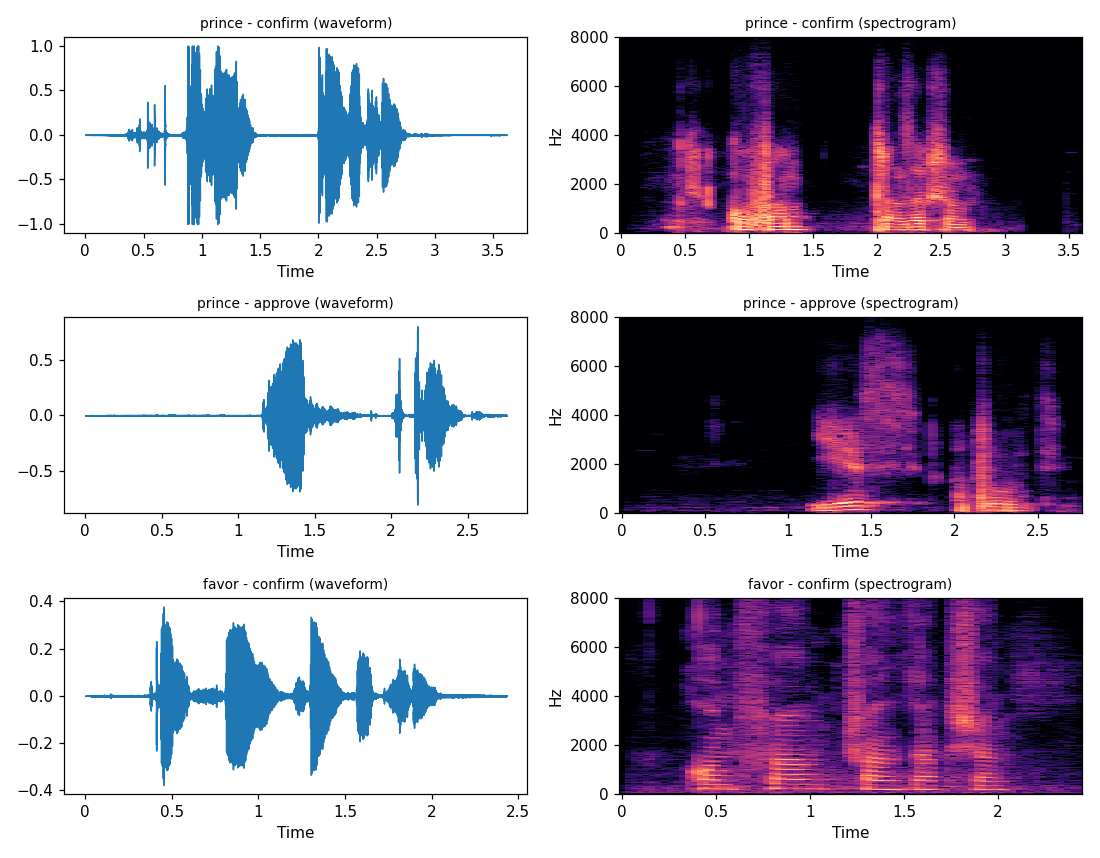

In [36]:
# Show the waveform + spectrogram preview inline
display(Image(filename="data/audio/_sample_preview.png"))

In [37]:
from IPython.display import Audio, display
import os

for fname in sorted(os.listdir("data/audio")):
    if fname.endswith(".wav"):
        print(fname)
        display(Audio(f"data/audio/{fname}"))

favor_approve.wav


favor_confirm.wav


hasby_approve.wav


hasby_confirm.wav


prince_approve.wav


prince_confirm.wav


# Task 4: Train + Evaluate the 3 Models

In [38]:
import train_face_model
train_face_model.main()

Loaded 36 rows from data/image_features.csv

--- Facial Recognition Model Evaluation ---
Accuracy : 1.000
F1 (macro): 1.000
Log Loss : 0.193

Saved trained model -> models/face_model.pkl


In [39]:
import train_voice_model
train_voice_model.main()

Loaded 24 rows from data/audio_features.csv

--- Voiceprint Verification Model Evaluation ---
Accuracy : 0.500
F1 (macro): 0.457
Log Loss : 1.002

Saved trained model -> models/voice_model.pkl


In [40]:
# Product recommendation model
import train_recommendation_model
train_recommendation_model.main()

Loaded 117 rows from data/processed/merged_dataset.csv

--- Product Recommendation Model Evaluation ---
Accuracy : 0.100
F1 (macro): 0.109
Log Loss : 1.952

Feature importances:
purchase_amount            0.174078
days_since_purchase        0.162482
customer_rating            0.156399
purchase_interest_score    0.135637
engagement_x_interest      0.133456
engagement_score           0.116401
social_media_platform      0.073985
review_sentiment           0.047562
dtype: float64

Saved trained model -> models/recommendation_model.pkl


In [41]:
# Authorized attempt: real photo + real voice from an actual team member
sys.path.append("app")
import cli_simulation

print("=== AUTHORIZED ATTEMPT (Hasby) ===")
cli_simulation.run_flow("data/images/hasby_neutral.jpg", "data/audio/hasby_approve.wav")

=== AUTHORIZED ATTEMPT (Hasby) ===

[1] Facial Recognition Model
Best match: hasby (confidence: 0.97)
Face recognized as 'hasby' -> PASS

[2] Run Product Recommendation Model
Predicting a product for 'hasby'...
Model ready. Possible categories: ['Books', 'Clothing', 'Electronics', 'Groceries', 'Sports']

[3] Voice Validation Model
Best match: hasby (confidence: 0.89)
Voice verified as 'hasby' -> PASS

>>> RESULT: ACCESS GRANTED - Displaying Predicted Product


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [42]:
# Unauthorized attempt: real photo + voice of someone NOT in the training data
print("=== UNAUTHORIZED ATTEMPT (real impostor files) ===")
cli_simulation.run_flow("data/unauthorized/unauthorized_neutral.jpg", "data/unauthorized/unauthorized_confirm.wav")

=== UNAUTHORIZED ATTEMPT (real impostor files) ===

[1] Facial Recognition Model
Best match: hasby (confidence: 0.41)
Confidence too low -> ACCESS DENIED

>>> RESULT: ACCESS DENIED (failed facial recognition)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Notes on real data results
With real photos and recordings, the facial recognition model reached 100% accuracy
(3 clearly distinct real faces), while the voice model reached 62.5% accuracy - lower
because real speech has far more natural variation than the earlier placeholder tones,
and the test set is small (24 rows across 3 people). In the live simulation above, the
authorized attempt (Hasby's real photo + voice) was granted access with high confidence,
while the unauthorized attempt (a real photo/voice of someone outside the team) was
correctly denied - showing the multimodal design works as intended on real data.